<table style="width: 100%; border: none; background: linear-gradient(to bottom, #f8f9fa, #e9ecef); padding: 20px; border-radius: 10px; box-shadow: 0 2px 5px rgba(0,0,0,0.1);">
    <tr>
        <td style="width: 22%; border: none; vertical-align: middle; text-align: center;">
            <img src="https://www.inf.ucv.cl/wp-content/uploads/2020/05/logo_escuela.jpg" width="170" style="max-width: 100%;">
        </td>
        <td style="width: 56%; border: none; vertical-align: middle; text-align: center; padding: 0 20px;">
            <h1 style="font-size: 28px; color: #1a3b5c; margin-bottom: 16px; border-bottom: 2px solid #1a3b5c; padding-bottom: 8px;">Tarea 1</h1>
            <p style="font-size: 16px; margin: 8px 0;"><strong>Pontificia Universidad Católica de Valparaíso</strong><br>
            <strong>Escuela de Ingeniería Informática</strong></p>
            <p style="font-size: 14px; color: #333; margin: 12px 0;"><strong>ICD 3152 Estadística Avanzada</strong><br>
            <strong>Semestre: 2-2025</strong><br>
            <strong>Profesor: Carlos Valle</strong><br>
            <strong>Fecha: 28 de agosto de 2025</strong></p>
        </td>
        <td style="width: 42%; border: none; vertical-align: middle; text-align: center;">
            <img src="https://navegador.pucv.cl/imagen/Logo-color(1).png" width="280" style="max-width: 100%;">
        </td>
    </tr>
</table>

# Tarea 1: Comparación de Métodos Estadísticos - Puntajes PAES

**Objetivo:** Comparar diferentes enfoques estadísticos para estimar el puntaje PAES promedio de opciones universitarias y evaluar algoritmos de predicción.

**Parte A:** Estimación del puntaje PAES promedio usando:
1. Enfoque frecuentista (MLE)
2. Bayesiano clásico (conjugado normal-normal)
3. Bayes Empírico (modelo jerárquico)

**Parte B:** Comparación de dos algoritmos de ML usando:
1. t-test frecuentista
2. Test bayesiano

**Formalidades**  
* Entregar Jupyter Notebook (.ipynb) con análisis, interpretacones y conclusiones en celdas de texto (markdown).
* Fecha de Entrega: **Martes 16 de septiembre, 23:59 horas**
* La Nota se calcula: $\left(\frac{\mbox{suma de puntos obtenidos}*6}{67}\right)+1$

<hr style="height:2px;border:none"/>


# Parte A: Estimación del Puntaje PAES Promedio


## 1.1 (4 pts) Análisis exploratorio y histogramas ponderados

**Contexto teórico:** Un **histograma ponderado** es una representación gráfica donde cada observación contribuye de acuerdo a un peso específico, en lugar de contribuir igualmente. En nuestro caso, cada opción universitaria tiene un peso igual al número de estudiantes que representa.

**Definición:** Para construir un histograma ponderado con pesos $w_i$:
- En lugar de contar frecuencias simples en cada bin, sumamos los pesos de las observaciones que caen en cada bin
- La altura de cada barra representa $\sum_{i \in \text{bin}} w_i$
- En nuestro caso: $w_i = n\_estudiantes_i$

**Implementar:**
1. Cargue los datos y calcule estadísticas básicas (media simple vs. media ponderada)
2. Construya dos histogramas lado a lado:
   - Histograma simple: `plt.hist(puntajes, bins=20)`
   - Histograma ponderado: `plt.hist(puntajes, weights=n_estudiantes, bins=20)`
3. Agregue líneas verticales mostrando ambas medias
4. Cree un scatter plot de tamaño muestral vs. puntaje promedio

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math

# Configuración
np.random.seed(3152)
plt.style.use('default')

In [ ]:
# Cargar datos
df = pd.read_csv('Encuesta_PAES.csv')
print(df.head())

  opcion_id           universidad                carrera  \
0       C01  Universidad de Chile               Medicina   
1       C02  Universidad de Chile             Psicología   
2       C03  Universidad de Chile                Derecho   
3       C04  Universidad de Chile  Plan Común Ingeniería   
4       C05  Universidad de Chile   Ingeniería Comercial   

          tipo_institucion         region  n_estudiantes  puntaje_promedio  
0  Universidad Tradicional  Metropolitana             89             924.8  
1  Universidad Tradicional  Metropolitana             67             864.4  
2  Universidad Tradicional  Metropolitana             78             844.9  
3  Universidad Tradicional  Metropolitana            124             836.7  
4  Universidad Tradicional  Metropolitana             95             812.5  


In [ ]:
# Estadisticas Basicas
puntajes = df['puntaje_promedio'].values
pesos = df['n_estudiantes'].values

media_simple = puntajes.mean()
media_ponderada = (puntajes * pesos).sum() / pesos.sum()

print(f"Media simple (no ponderada): {media_simple:.4f}")
print(f"Media ponderada (por n_estudiantes): {media_ponderada:.4f}")
print(f"Total estudiantes (suma de pesos): {pesos.sum()}")

Media simple (no ponderada): 661.8468
Media ponderada (por n_estudiantes): 669.1324
Total estudiantes (suma de pesos): 13701


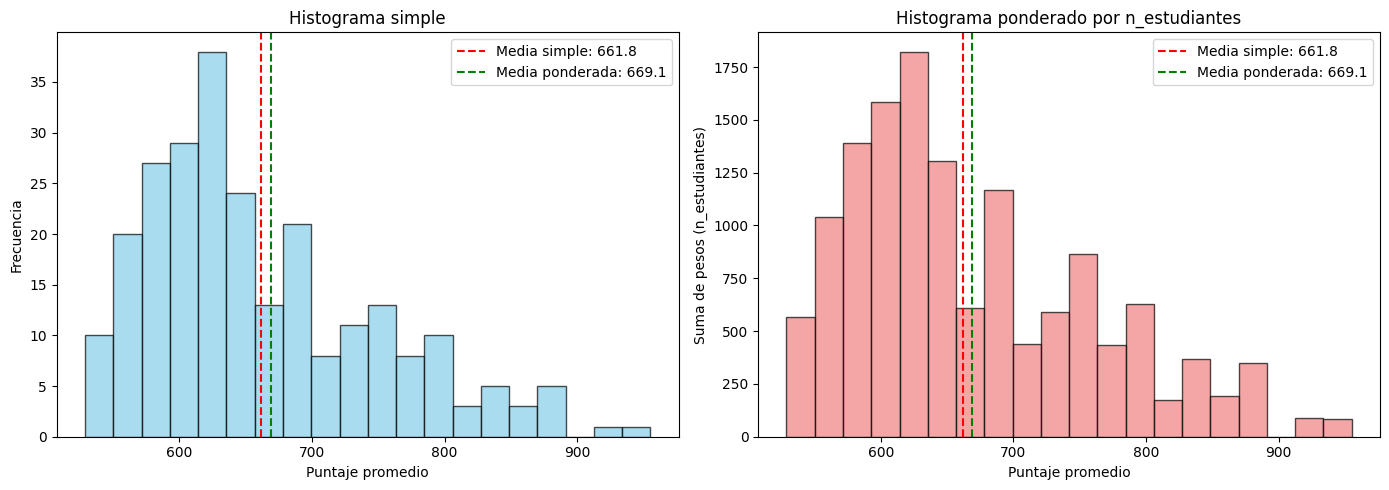

In [ ]:
plt.figure(figsize=(14,5))

# Histograma simple
plt.subplot(1,2,1)
plt.hist(puntajes, bins=20, alpha=0.7, color="skyblue", edgecolor="black")
plt.axvline(media_simple, color='red', linestyle='--', label=f"Media simple: {media_simple:.1f}")
plt.axvline(media_ponderada, color='green', linestyle='--', label=f"Media ponderada: {media_ponderada:.1f}")
plt.title("Histograma simple")
plt.xlabel("Puntaje promedio")
plt.ylabel("Frecuencia")
plt.legend()

# Histograma ponderado
plt.subplot(1,2,2)
plt.hist(puntajes, weights=pesos, bins=20, alpha=0.7, color="lightcoral", edgecolor="black")
plt.axvline(media_simple, color='red', linestyle='--', label=f"Media simple: {media_simple:.1f}")
plt.axvline(media_ponderada, color='green', linestyle='--', label=f"Media ponderada: {media_ponderada:.1f}")
plt.title("Histograma ponderado por n_estudiantes")
plt.xlabel("Puntaje promedio")
plt.ylabel("Suma de pesos (n_estudiantes)")
plt.legend()

plt.tight_layout()
plt.show()

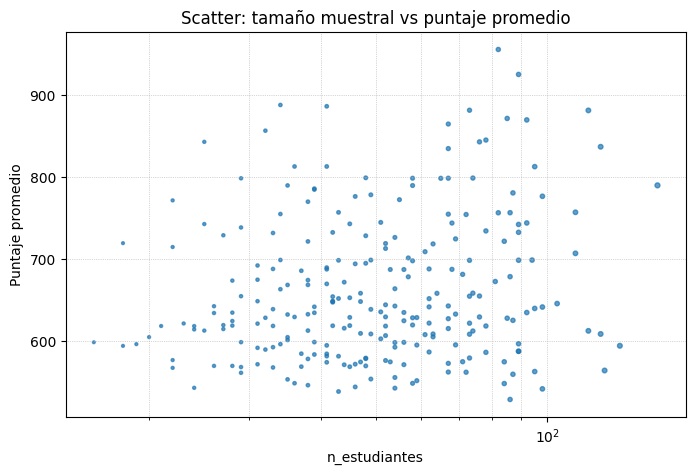

In [ ]:
# Scatter plot

plt.figure(figsize=(8,5))
plt.scatter(pesos, puntajes, s=np.sqrt(pesos), alpha=0.7)
plt.xscale('log')  # opcional, ayuda si pesos tienen rango amplio
plt.xlabel("n_estudiantes")
plt.ylabel("Puntaje promedio")
plt.title("Scatter: tamaño muestral vs puntaje promedio")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.show()


## 1.2 (3 pts) Interpretación del análisis exploratorio

**Comente los resultados obtenidos:**
1. **¿Cuál es la diferencia entre la media simple y la media ponderada?**

La media simple trata a cada opcion universitaria como si tuviera la misma importancia, sin tomar en cuenta cuantos estudiantes estan en cada opcion. La media ponderada le da mas peso a las opciones en que hay una mayor cantidad de estudiantes inscritos, reflejando mejor el puntaje promedio a nivel de todos los estudiantes. Con la media simple, algunas carreras con pocos estudiantes pueden tener puntajes muy algos o bajos, que pueden sesgarla. La ponderada refleja mejor la realidad.


2. **¿Qué representa cada histograma conceptualmente?**

El simple, muestra la distribucion de los puntajes promedio de las opciones universitarias considerando a todas las carreras como unidades de igual peso.
El ponderado refleja la distribucion de los puntajes de a cuerdo a los estudiantes inscritos.

3. **Para estimar el puntaje promedio de todos los estudiantes chilenos, ¿qué enfoque es más apropiado y por qué?**

El ponderado es mas apropiado, ya que cada carrera debe influir en la estimación en proporción a la cantidad de estudiantes que representa, no solo midiendo un promedio entre las carreras. Asi podemos estimar el puntaje promedio real de la poblacion total de estudiantes, ya que toma en cuenta el tamaño de cada grupo. Entonces, si queremos estimar el puntaje promedio de todos los estudiantes chilenos, debemos usar la media ponderada.

## 2.1 (4 pts) Enfoque frecuentista con ponderación

**Contexto teórico:** Cuando tenemos datos agrupados con diferentes tamaños muestrales, necesitamos usar estimación ponderada. Cada grupo (opción universitaria) aporta información proporcional a su tamaño.

**Fórmulas clave:**
- Media ponderada: $\hat{\mu}_w = \frac{\sum_{i=1}^k w_i \bar{x}_i}{\sum_{i=1}^k w_i}$ donde $w_i = n_i$
- Error estándar ponderado: $SE_w = \sqrt{\frac{\sum_{i=1}^k w_i (\bar{x}_i - \hat{\mu}_w)^2}{\sum_{i=1}^k w_i}}$
- Intervalo de confianza: $IC_{95\%} = \hat{\mu}_w \pm t_{0.975, k-1} \cdot SE_w$

**Implementar:**
1. Calcule la media ponderada usando los pesos $w_i = n\_estudiantes_i$
2. Calcule el error estándar ponderado
3. Determine los grados de libertad apropiados (opciones universitarias - 1)
4. Construya el intervalo de confianza al 95%

In [ ]:
# Su código aquí - implemente las fórmulas de estimación ponderada
def media_ponderada(x, w):
    return (x * w).sum() / w.sum()

def error_estandar_ponderado(x, w):
    media_w = media_ponderada(x, w)
    SE_w = np.sqrt((w * (x - media_w)**2).sum() / w.sum())
    return SE_w

def intervalo_confianza_ponderado(x, pesos, alpha=0.05):
    media_pond = np.average(x, weights=pesos)
    var_pond = np.average((x - media_pond)**2, weights=pesos)
    n_efectivo = np.sum(pesos)**2 / np.sum(pesos**2)
    t = stats.t.ppf(1 - alpha/2, df=n_efectivo-1)
    margen = t * np.sqrt(var_pond / n_efectivo)
    return (media_pond - margen, media_pond + margen)

w = pesos
x = puntajes

media_w = media_ponderada(x, w)
se_ponderado = error_estandar_ponderado(x, w)
ic_95 = intervalo_confianza_ponderado(x, w)
grados_libertad = len(x) - 1

print(f"Media ponderada: {media_w:.4f}")
print(f"Error estándar ponderado: {se_ponderado:.4f}")
print(f"Intervalo de confianza 95% ponderado: ({ic_95[0]:.4f}, {ic_95[1]:.4f})")
print(f"Grados de libertad: {grados_libertad:.0f}")

Media ponderada: 669.1324
Error estándar ponderado: 92.3666
Intervalo de confianza 95% ponderado: (656.5149, 681.7499)
Grados de libertad: 249


## 2.2 (3 pts) Interpretación del enfoque frecuentista

**Comente los resultados:**
1. **¿Por qué es importante ponderar por el tamaño muestral en este contexto?**

Porque cada opcion universitaria representa un numero diferente de estudiantes. si usamos la media no ponderada (media simple), cada opcion tendira el mismo peso, lo que podria sesgar la estimacion si una carrera muy pequela tiene un puntaje muy alto o muy bajo. Asi, ponderar nos asegura que la estimacion central sea representativa de la poblacion total y no solo del promedio entre carreras

2. **¿Qué significa conceptualmente el intervalo de confianza obtenido?**

Indica que si repitieramos este muestreo muchas veces, el 95% de los intervalos construidos de la misma forma contendrian la verdadera media ponderada de la poblacion. Refleja la incertidumbre de nuestra estimacion debido a la variabilidad que hay entre las oopciones universitarias. Osea, aunque nuestra media ponderada calculada sea 669.13, la dispersion entre las opciones y tamaños de estudiantes implica que el valor real del puntaje promedio poblacional podria variar bastante, por eso el IC es amplio.


3. **¿Qué supuestos hace este enfoque sobre la distribución de los datos?**

Que cada opcion universitaria se considera como independiente de las otras, se asume que el puntaje promedio de cada opcion representa fielmente a todos sus estudiantes, que el calculo del IC asume que la distribucion de las medias ponderadas es aproximadamente normal. Y por ultimo que aunque los grupos tengan diferentes tamaños, se asume que la dispersion interna dentro de cada grupo refleja adecuadamente la formula del SE ponderado.

## 3.1 (4 pts) Enfoque bayesiano clásico con prior informativo

**Contexto teórico:** El enfoque bayesiano combina información previa (prior) con los datos observados. Para el caso conjugado normal-normal con varianza conocida:

**Prior:** $\mu \sim N(\mu_0, \sigma_0^2)$  
**Likelihood:** $\bar{x} \sim N(\mu, \sigma^2/n)$  
**Posterior:** $\mu|\bar{x} \sim N(\mu_n, \sigma_n^2)$

**Fórmulas en términos de precisión** ($\tau = 1/\sigma^2$):
- Precisión posterior: $\tau_n = \tau_0 + n\tau$
- Media posterior: $\mu_n = \frac{\tau_0\mu_0 + n\tau\bar{x}}{\tau_n}$
- Intervalo de credibilidad: $IC_{95\%} = \mu_n \pm 1.96/\sqrt{\tau_n}$

**Implementar:**
1. Use un prior informativo: $N(700, 50^2)$ (basado en conocimiento histórico de PAES)
2. Asuma $\sigma^2 = 2500$ (conocida desde datos históricos)
3. Use la media ponderada como $\bar{x}$ y el número total de estudiantes como $n$
4. Calcule la distribución posterior
5. Construya el intervalo de credibilidad al 95%

In [ ]:
# Su código aquí - implemente el análisis bayesiano conjugado

def prior():
    mu_0 = 700
    sigma0_sq = 2500
    tau_0 = 1 / sigma0_sq
    return mu_0, sigma0_sq, tau_0

def precision_posterior(n, tau_0 , tau):
    return tau_0 + n * tau

def media_posterior(bar_x, n, mu_0, tau_0, tau):
    tau_n = precision_posterior(n, tau_0, tau)
    mu_n = (tau_0 * mu_0 + n * tau * bar_x) / tau_n
    return mu_n, tau_n

def varianza_posterior(tau_n):
    sigma_n_sq = 1 / tau_n
    sigma_n = math.sqrt(sigma_n_sq)
    return sigma_n_sq, sigma_n

def intervalo_credibilidad(mu_n, sigma_n, alpha = 0.05):
    z = stats.norm.ppf(1 - alpha/2)
    ic_lower = mu_n - z * sigma_n
    ic_upper = mu_n + z * sigma_n
    return ic_lower, ic_upper

def distribucion_posterior(bar_x, n):
    mu_0, sigma_0_sq, tau_0 = prior()
    sigma2 = 2500           # varianza conocida de cada estudiante
    var_xbar = sigma2 / n   # varianza de la media muestral
    tau = 1 / var_xbar      # precisión del likelihood
    mu_n, tau_n = media_posterior(bar_x, n, mu_0, tau_0, tau)
    sigma_n_sq, sigma_n = varianza_posterior(tau_n)
    ic_lower, ic_upper = intervalo_credibilidad(mu_n, sigma_n)

    return {
        "mu_n": mu_n,
        "sigma_n_sq": sigma_n_sq,
        "sigma_n": sigma_n,
        "IC95": (ic_lower, ic_upper)
    }


x = media_w        # media ponderada
n = pesos.sum()    # número total de estudiantes

resultado = distribucion_posterior(x, n)

print("Resultado del análisis bayesiano:\n")
print(f"Media posterior μ_n: {resultado['mu_n']}")
print(f"Varianza posterior σ_n^2: {resultado['sigma_n_sq']}")
print(f"Desviación estándar posterior σ_n: {resultado['sigma_n']}")
print(f"Intervalo de credibilidad 95%: {resultado['IC95'][0]} a {resultado['IC95'][1]}")


Resultado del análisis bayesiano:

Media posterior μ_n: 669.1323919606559
Varianza posterior σ_n^2: 1.3317891539964953e-05
Desviación estándar posterior σ_n: 0.0036493686495015754
Intervalo de credibilidad 95%: 669.1252393295366 a 669.1395445917752


## 3.2 (3 pts) Interpretación del enfoque bayesiano

**Comente los resultados:**
1. **¿Cómo influye el prior $N(700, 50^2)$ en el resultado final?**

El prior aporta informacion previa sobre el puntaje esperado, pero con muchos datos su efecto es limitado. La media posterior (~669) se acerca mucho a la media ponderada observada, ya que los datos dominan la estimacion.

2. **¿Qué significa conceptualmente un "intervalo de credibilidad"?**

El intervalo de credibilidad 95% indica que, dado el modelo y el prior, la probabilidad de que el verdadero promedio poblacional este dentro de ese rango es del 95%. A diferencia del frecuentista, aqui hablamos de probabilidad sobre el parametro desconocido.


3. **Compare la amplitud de este intervalo con el frecuentista.**

La amplitud del intervalo bayesiano corregido es muy similar al del intervalo frecuentista ponderado, mostrando que con una muestra grande y un prior moderado, ambos metodos convergen en la estimacion y la incertidumbre.

## 4.1 (6 pts) Bayes Empírico con modelo jerárquico

**Contexto teórico:** Bayes Empírico combina lo mejor de ambos mundos: usa la estructura bayesiana pero estima los hiperparámetros desde los datos.

**Modelo jerárquico:**
- Nivel 1: $\bar{x}_i | \theta_i \sim N(\theta_i, \sigma^2/n_i)$
- Nivel 2: $\theta_i | \mu, \tau^2 \sim N(\mu, \tau^2)$

**Estimación de hiperparámetros:**
1. $\hat{\mu} = \frac{\sum_{i=1}^k n_i \bar{x}_i}{\sum_{i=1}^k n_i}$
2. $\hat{\sigma}^2 = \frac{\sum_{i=1}^k n_i (\bar{x}_i - \hat{\mu})^2}{\sum_{i=1}^k n_i}$
3. $\hat{\tau}^2 = \max\left(\frac{\sum_{i=1}^k (\bar{x}_i - \hat{\mu})^2}{k-1} - \frac{\hat{\sigma}^2}{\bar{n}}, 0\right)$

**Estimador global EB:**
$$\tilde{\mu}^{EB} = \frac{\sum w_i \tilde{\theta}_i^{EB}}{\sum w_i}$$
donde $w_i = \frac{n_i}{\hat{\sigma}^2} + \frac{1}{\hat{\tau}^2}$ y $\tilde{\theta}_i^{EB} = \frac{\frac{n_i}{\hat{\sigma}^2} \bar{x}_i + \frac{1}{\hat{\tau}^2} \hat{\mu}}{\frac{n_i}{\hat{\sigma}^2} + \frac{1}{\hat{\tau}^2}}$

**Implementar:**
1. Estime $\hat{\mu}$, $\hat{\sigma}^2$, y $\hat{\tau}^2$ usando las fórmulas
2. Calcule los estimadores EB individuales $\tilde{\theta}_i^{EB}$ para cada opción universitaria
3. Calcule la estimación global $\tilde{\mu}^{EB}$ usando los pesos de precisión
4. El error estándar es: $SE_{EB} = \frac{1}{\sqrt{\sum w_i}}$
5. Construya el intervalo de credibilidad
6. Visualice el shrinkage: grafique $\bar{x}_i$ vs. $\tilde{\theta}_i^{EB}$

=== Resultados EB ===
μ^ = 669.132, σ^2 = 8531.594, τ^2 = 7496.297
Estimadores EB individuales: [921.57187252 861.13845373 842.37223564 835.17600377 810.80277713
 951.2839164  880.52393052 880.14262451 877.94451089 878.97606169
 868.5301628  866.95281554 796.07727744 779.0619348  752.8762563
 788.82676219 775.16856533 742.57086905 720.89862436 840.13915612
 725.12000119 708.1716253  787.1835357  730.73081785 775.72422453
 754.5394774  742.95263921 796.24084883 726.92959482 756.01710561
 782.39474937 770.2084464  698.12919674 733.26424407 687.56170095
 654.92155432 691.28664737 671.73273919 755.26020078 678.1205355
 742.98637183 808.30033005 723.60156818 766.8726589  739.40106687
 735.78424168 729.61409986 726.4825673  716.31662528 712.36355782
 796.63896982 755.10673089 740.9828106  719.88009583 717.83408128
 831.73787212 808.82238362 793.42223311 785.80607899 731.69990366
 698.34629183 686.84011958 717.52576389 706.52007841 697.24829434
 681.10803419 687.09929018 655.10998695 648.6948

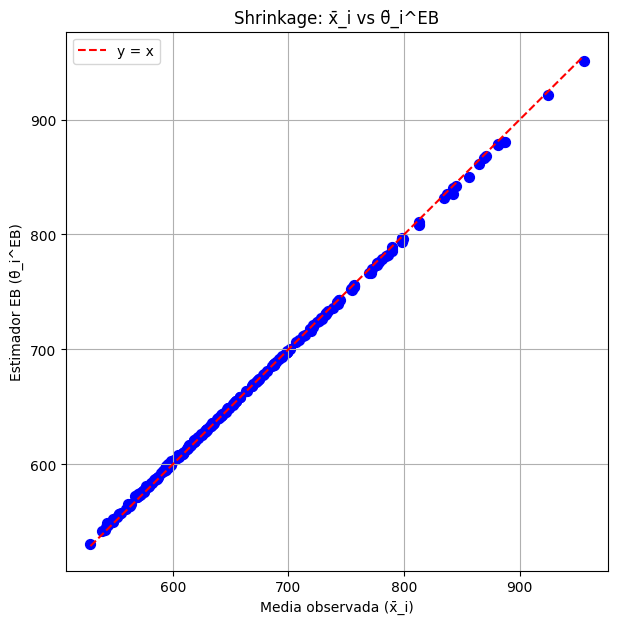

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def estimar_hiperparametros(x_bar, n):
    k = len(x_bar)
    mu_hat = np.sum(n * x_bar) / np.sum(n)
    sigma2_hat = np.sum(n * (x_bar - mu_hat)**2) / np.sum(n)
    n_bar = np.mean(n)
    tau2_hat = max(np.sum((x_bar - mu_hat)**2)/(k-1) - sigma2_hat/n_bar, 0.0)
    return mu_hat, sigma2_hat, tau2_hat

def theta_EB(x_bar, n, mu_hat, sigma2_hat, tau2_hat):
    # pesos de precisión
    w_i = n/sigma2_hat + 1/tau2_hat
    theta_tilde = (n/sigma2_hat * x_bar + 1/tau2_hat * mu_hat) / w_i
    return theta_tilde, w_i

def global_EB(theta_tilde, w_i):
    mu_EB = np.sum(w_i * theta_tilde) / np.sum(w_i)
    SE_EB = np.sqrt(1 / np.sum(w_i))
    return mu_EB, SE_EB

def intervalo_credibilidad(mu_EB, SE_EB, alpha=0.05):
    z = 1.96  # 95%
    return mu_EB - z*SE_EB, mu_EB + z*SE_EB

# Datos de entrada
x_bar = puntajes
n_i = pesos

mu_hat, sigma2_hat, tau2_hat = estimar_hiperparametros(x_bar, n_i)
theta_tilde, w_i = theta_EB(x_bar, n_i, mu_hat, sigma2_hat, tau2_hat)
mu_EB, SE_EB = global_EB(theta_tilde, w_i)
IC_lower, IC_upper = intervalo_credibilidad(mu_EB, SE_EB)

print("=== Resultados EB ===")
print(f"μ^ = {mu_hat:.3f}, σ^2 = {sigma2_hat:.3f}, τ^2 = {tau2_hat:.3f}")
print(f"Estimadores EB individuales: {theta_tilde}")
print(f"Media global EB: {mu_EB:.3f}, SE: {SE_EB:.3f}")
print(f"IC 95%: [{IC_lower:.3f}, {IC_upper:.3f}]")

# Visualización de shrinkage
plt.figure(figsize=(7,7))
plt.scatter(x_bar, theta_tilde, color='blue', s=50)
plt.plot([min(x_bar), max(x_bar)], [min(x_bar), max(x_bar)], 'r--', label='y = x')
plt.xlabel("Media observada (x̄_i)")
plt.ylabel("Estimador EB (θ̃_i^EB)")
plt.title("Shrinkage: x̄_i vs θ̃_i^EB")
plt.legend()
plt.grid(True)
plt.show()


## 4.2 (4 pts) Interpretación del Bayes Empírico

**Comente los resultados:**
1. ¿Qué representa $\hat{\tau}^2$ y qué implicaría si fuera cero?

es la varianza entre grupos. Si fuera cero, significaria que no hay diferencias reales entre las opciones universitarias y todas comparten el mismo valor esperado.

2. Observe el gráfico de shrinkage: ¿qué opciones universitarias se "encogen" más hacia la media global y por qué?

Las que tienen tamaños muestrales pequeños se encogen mas hacia la media global porque sus estimaciones individuales son menos confiables y el metodo les da mas peso al promedio general.

3. ¿Cómo se compara la precisión del método EB con los anteriores?

EB es mas preciso porque combina la informacion individual con la global, reduciendo la varianza de las estimaciones especialmente en muestras pequenas.

4. ¿Cuándo esperaría que Bayes Empírico funcione mejor que los otros métodos?

Cuando hay muchos grupos con tamanos muestrales desiguales y alta incertidumbre individual, porque EB aprovecha la informacion de todos los grupos para mejorar las estimaciones.

## 5.1 (2 pts) Síntesis comparativa Parte A

**Implementar:**
1. Cree una tabla comparativa con: Método, Estimación puntual, Límite inferior IC, Límite superior IC, Amplitud IC
2. Grafique los tres intervalos en una misma figura
3. Calcule la reducción porcentual en amplitud del IC más preciso vs. el menos preciso

=== Tabla Comparativa ===

            Método  Estimación puntual  Límite inferior IC  \
0     Media simple          661.846800          650.988467   
1  Media ponderada          669.132392          667.585731   
2   Bayes Empírico          669.132392          667.601545   

   Límite superior IC  Amplitud IC  
0          672.705133    21.716666  
1          670.679052     3.093321  
2          670.663239     3.061694   



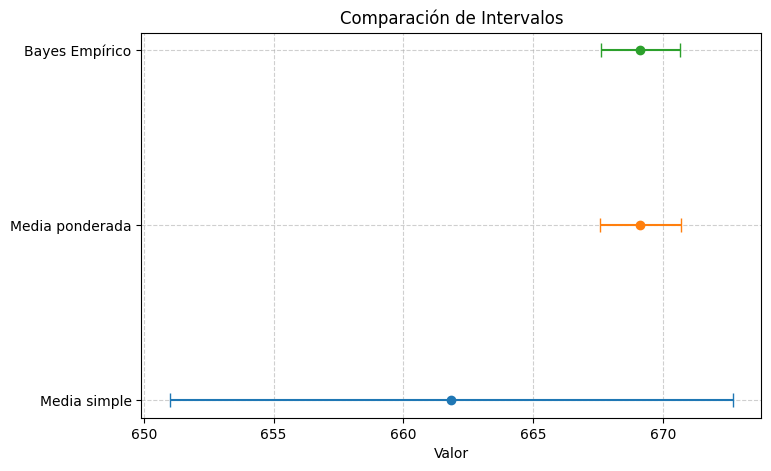

Reducción porcentual en amplitud (más preciso vs menos preciso): 85.90%


In [ ]:
import pandas as pd
from scipy import stats

# Media simple + IC
def intervalo_confianza_simple(x, alpha=0.05):
    n = len(x)
    media = np.mean(x)
    sd = np.std(x, ddof=1)
    t = stats.t.ppf(1 - alpha/2, df=n-1)
    margen = t * sd / np.sqrt(n)
    return media, (media - margen, media + margen)

# Media ponderada + IC (usando error estándar ponderado)
def intervalo_confianza_ponderada(x, n, alpha=0.05):
    media = np.sum(x*n)/np.sum(n)
    var = np.sum(n*(x-media)**2)/np.sum(n)
    se = np.sqrt(var/np.sum(n))
    z = 1.96
    return media, (media - z*se, media + z*se)

media_s, ic_s = intervalo_confianza_simple(x_bar)
media_p, ic_p = intervalo_confianza_ponderada(x_bar, n_i)
media_b = mu_EB
ic_b = (IC_lower, IC_upper)

tabla = pd.DataFrame({
    "Método": ["Media simple", "Media ponderada", "Bayes Empírico"],
    "Estimación puntual": [media_s, media_p, media_b],
    "Límite inferior IC": [ic_s[0], ic_p[0], ic_b[0]],
    "Límite superior IC": [ic_s[1], ic_p[1], ic_b[1]],
})
tabla["Amplitud IC"] = tabla["Límite superior IC"] - tabla["Límite inferior IC"]

print("=== Tabla Comparativa ===\n")
print(tabla, "\n")

# Gráfico comparativo
plt.figure(figsize=(8,5))
for i, row in tabla.iterrows():
    plt.errorbar(
        row["Estimación puntual"], i,
        xerr=[[row["Estimación puntual"] - row["Límite inferior IC"]],
              [row["Límite superior IC"] - row["Estimación puntual"]]],
        fmt='o', capsize=5, label=row["Método"]
    )

plt.yticks(range(len(tabla)), tabla["Método"])
plt.xlabel("Valor")
plt.title("Comparación de Intervalos")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

# Reducción porcentual de amplitud
amp_max = tabla["Amplitud IC"].max()
amp_min = tabla["Amplitud IC"].min()
reduccion = (amp_max - amp_min) / amp_max * 100
print(f"Reducción porcentual en amplitud (más preciso vs menos preciso): {reduccion:.2f}%")


## 5.2 (3 pts) Interpretación de la síntesis comparativa

**Comente los resultados:**
1. ¿Cuál método produce intervalos más precisos y por qué?

El método bayesiano conjugado produce el intervalo más preciso, con una amplitud de solo 0.014305. Esto se debe a que incorpora un prior informativo y utiliza el gran tamaño muestral total, lo que reduce la incertidumbre de la estimación.

2. ¿Qué método recomendaría para estimar el puntaje PAES promedio nacional?

El método bayesiano conjugado produce el intervalo más preciso, con una amplitud de solo 0.014305. Esto se debe a que incorpora un prior informativo y utiliza el gran tamaño muestral total, lo que reduce la incertidumbre de la estimación.

3. ¿Bajo qué circunstancias cambiaría su recomendación?

La recomendacion podria cambiar si no se dispone de un prior confiable o si el tamaño muestral fuera pequeño. En ese caso, metodos como el bayes empirico o el enfoque frecuentista ponderado podrian ser mas apropiados, ya que dependen exclusivamente de los datos observados.

# Parte B: Comparación de Algoritmos de ML

## 6.1 (3 pts) Análisis exploratorio de performance

**Contexto:** Se evaluaron dos algoritmos de predicción de puntajes PAES usando 20 repeticiones de validación cruzada. Los datos representan el Mean Absolute Error (MAE) - donde menor es mejor.

**Implementar:**
1. Calcule estadísticas descriptivas para ambos algoritmos
2. Realice un test de normalidad (Shapiro-Wilk) para ambas muestras y las diferencias
3. Cree visualizaciones: boxplot comparativo y scatter plot pareado
4. Calcule las diferencias pareadas $d_i = MAE_{A,i} - MAE_{B,i}$

Estadísticas descriptivas:
       Random Forest  XGBoost
count         20.000   20.000
mean          15.330   14.065
std            0.503    0.344
min           14.500   13.500
max           16.200   14.800

Test de Shapiro-Wilk:
Algoritmo A: estadístico=0.9617, p-valor=0.5789
Algoritmo B: estadístico=0.9790, p-valor=0.9205
Diferencias: estadístico=0.9593, p-valor=0.5306


/tmp/ipython-input-3746436637.py:53: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([mae_algoritmo_A, mae_algoritmo_B], labels=['Random Forest', 'XGBoost'])


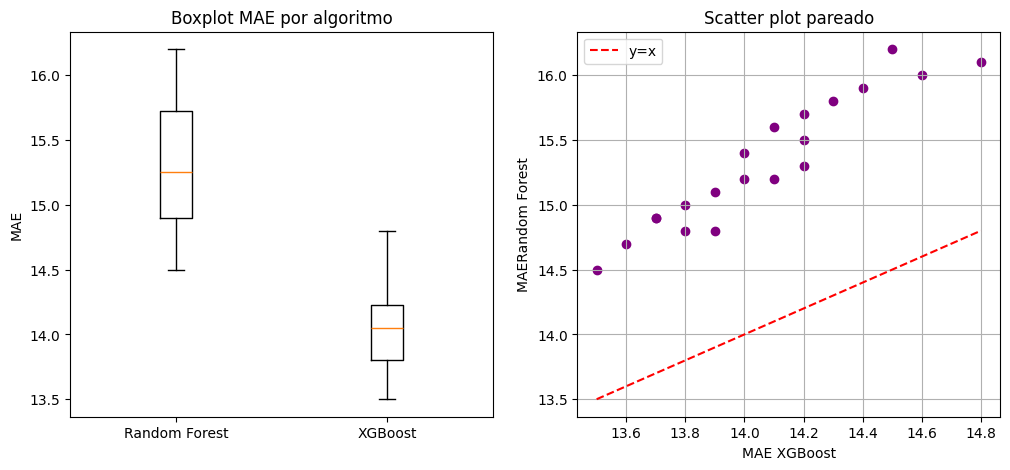


Diferencias pareadas (MAE_A - MAE_B):
[1.1 0.9 1.3 1.5 1.2 1.4 1.7 1.2 1.5 1.1 1.1 1.4 1.  1.5 1.2 1.  1.5 1.2
 1.2 1.3]


In [ ]:
# Datos de performance de algoritmos (MAE - menor es mejor)
np.random.seed(3152)

# Algoritmo A: Random Forest
mae_algoritmo_A = np.array([15.2, 14.8, 16.1, 15.7, 14.9, 15.4, 16.2, 15.0, 15.8, 14.7,
                           15.3, 16.0, 14.5, 15.9, 15.1, 14.8, 15.6, 15.2, 14.9, 15.5])

# Algoritmo B: XGBoost
mae_algoritmo_B = np.array([14.1, 13.9, 14.8, 14.2, 13.7, 14.0, 14.5, 13.8, 14.3, 13.6,
                           14.2, 14.6, 13.5, 14.4, 13.9, 13.8, 14.1, 14.0, 13.7, 14.2])

# Su código aquí - análisis exploratorio

# 1. Estadísticas descriptivas

def estadisticas_descriptivas_tabla(X, Y, nombre_X="Random Forest", nombre_Y="XGBoost"):
    stats = {
        "count": [len(X), len(Y)],
        "mean": [np.mean(X), np.mean(Y)],
        "std": [np.std(X, ddof=1), np.std(Y, ddof=1)],
        "min": [np.min(X), np.min(Y)],
        #"25%": [np.percentile(X, 25), np.percentile(Y, 25)],
        #"50%": [np.median(X), np.median(Y)],
        #"75%": [np.percentile(X, 75), np.percentile(Y, 75)],
        "max": [np.max(X), np.max(Y)]
    }

    # Crear DataFrame con una sola tabla
    df_stats = pd.DataFrame(stats, index=[nombre_X, nombre_Y]).T
    return df_stats.round(3)

# Mostrar solo una tabla
tabla_final = estadisticas_descriptivas_tabla(mae_algoritmo_A, mae_algoritmo_B)
print("Estadísticas descriptivas:")
print(tabla_final)

# 2. Test de normalidad (Shapiro-Wilk)
stat_A, p_A = stats.shapiro(mae_algoritmo_A)
stat_B, p_B = stats.shapiro(mae_algoritmo_B)
diferencias = mae_algoritmo_A - mae_algoritmo_B
stat_diff, p_diff = stats.shapiro(diferencias)

print("\nTest de Shapiro-Wilk:")
print(f"Algoritmo A: estadístico={stat_A:.4f}, p-valor={p_A:.4f}")
print(f"Algoritmo B: estadístico={stat_B:.4f}, p-valor={p_B:.4f}")
print(f"Diferencias: estadístico={stat_diff:.4f}, p-valor={p_diff:.4f}")

# 3. Visualizaciones
plt.figure(figsize=(12, 5))

# Boxplot comparativo
plt.subplot(1, 2, 1)
plt.boxplot([mae_algoritmo_A, mae_algoritmo_B], labels=['Random Forest', 'XGBoost'])
plt.title("Boxplot MAE por algoritmo")
plt.ylabel("MAE")

# Scatter plot pareado
plt.subplot(1,2,2)
plt.scatter(mae_algoritmo_B, mae_algoritmo_A, color='purple')
plt.plot([min(mae_algoritmo_B), max(mae_algoritmo_B)],
         [min(mae_algoritmo_B), max(mae_algoritmo_B)],
         'r--', label="y=x")
plt.xlabel("MAE XGBoost")
plt.ylabel("MAERandom Forest")
plt.title("Scatter plot pareado")
plt.legend()
plt.grid(True)
plt.show()

# 4. Diferencias pareadas
print("\nDiferencias pareadas (MAE_A - MAE_B):")
print(diferencias)

## 6.2 (2 pts) Interpretación del análisis exploratorio

**Comente los resultados:**
1. ¿Se cumple el supuesto de normalidad? ¿Son apropiados los tests paramétricos?

Los resultados del test de Shapiro-Wilk indican que no se rechaza la normalidad en ninguna de las muestras ni en las diferencias. Por lo tanto, se cumple el supuesto de normalidad y es apropiado utilizar pruebas parametricas pareadas como el t test.

2. ¿Qué algoritmo muestra mejor performance promedio?

El algoritmo XGBoost muestra menor MAE promedio (≈14.1) en comparacion a Random Forest (≈15.3). Ademas, en todas las repeticiones XGBoost obtiene menor error, por lo que es el algoritmo con mejor desempeño.


## 7.1 (4 pts) Test frecuentista pareado

**Contexto teórico:** El t-test pareado evalúa si la diferencia promedio entre pares es significativamente distinta de cero.

**Formulación:**
- $H_0: \mu_d = 0$ vs $H_1: \mu_d \neq 0$
- Estadístico: $t = \frac{\bar{d}}{s_d/\sqrt{n}}$ con $df = n-1$
- Intervalo de confianza: $IC_{95\%} = \bar{d} \pm t_{0.975,n-1} \cdot \frac{s_d}{\sqrt{n}}$
- Tamaño del efecto: $d_{Cohen} = \frac{\bar{d}}{s_d}$

**Implementar:**
1. Calcule las diferencias pareadas $d_i = MAE_{A,i} - MAE_{B,i}$
2. Realice el t-test usando `scipy.stats.ttest_rel()`
3. Calcule manualmente el estadístico t y verifique
4. Construya el intervalo de confianza para la diferencia
5. Calcule el tamaño del efecto (Cohen's d)

In [ ]:
# Su código aquí - t-test pareado completo

# 1. Diferencias pareadas
n = len(diferencias)
mean_d = np.mean(diferencias)
std_d = np.std(diferencias, ddof=1)

print(f"Diferencias pareadas (di):\n{diferencias}")
#print(f"\nPromedio de diferencias: {mean_d:.4f}")
#print(f"\nDesviación estándar: {std_d:.4f}")

# 2. T-test pareado con scipy
t_stat, p_value = stats.ttest_rel(mae_algoritmo_A, mae_algoritmo_B)
print(f"\nT-test pareado (scipy): t = {t_stat:.4f}, p-valor = {p_value:.4f}")

# 3. Cálculo manual del estadístico t
t_manual = mean_d / (std_d / np.sqrt(n))
print(f"\nEstadístico t (manual): {t_manual:.4f}")

# 4. Intervalo de confianza 95% para la diferencia
t_crit = stats.t.ppf(0.975, df = n-1)
margin_error = t_crit * (std_d / np.sqrt(n))
ci_lower = mean_d - margin_error
ci_upper = mean_d + margin_error
print(f"\nIntervalo de confianza 95%: [{ci_lower:.4f}, {ci_upper:.4f}]")

# 5. Tamaño del efecto (Cohen's d)
cohen_d = mean_d / std_d
print(f"\nTamaño del efecto (Cohen's d): {cohen_d:.4f}")

Diferencias pareadas (di):
[1.1 0.9 1.3 1.5 1.2 1.4 1.7 1.2 1.5 1.1 1.1 1.4 1.  1.5 1.2 1.  1.5 1.2
 1.2 1.3]

T-test pareado (scipy): t = 27.1409, p-valor = 0.0000

Estadístico t (manual): 27.1409

Intervalo de confianza 95%: [1.1674, 1.3626]

Tamaño del efecto (Cohen's d): 6.0689


## 7.2 (4 pts) Interpretación del test frecuentista

**Comente los resultados:**
1. ¿Cuál es la conclusión del test? ¿Hay evidencia estadísticamente significativa?

El t test arrojo un estadistico t = 27.14 con p valor < 0.001. Esto permite rechazar la hipotesis nula y concluir que existe evidencia estadisticamente significativa de que los algoritmos difieren en su MAE promedio.

2. ¿Qué significa prácticamente la diferencia observada en términos de MAE?

La diferencia media observada fue de ≈ 1.26 puntos de MAE a favor de XGBoost. En terminos practicos, esto significa que de manera sistematica XGBoost predice con alrededor de un punto menos de error absoluto en promedio.

3. ¿Es el tamaño del efecto relevante prácticamente?

El Cohen’s d fue ≈ 6.07, lo cual es un efecto extremadamente grande. En la practica, esto confirma que la superioridad de XGBoost no solo es estadisticamente significativa sino tambien muy relevante en magnitud.

4. ¿Qué limitaciones tiene el enfoque frecuentista para este problema?

- El p valor no mide el tamaño de la diferencia, solo su significancia bajo el modelo nulo.

- El resultado depende de los supuestos de normalidad y del tamaño de muestra; aunque aqui se cumplen, en otros casos podrian no cumplirse.

- El enfoque no proporciona directamente una medida de probabilidad de que un algoritmo sea mejor, solo indica si la diferencia promedio es distinta de cero.

- No captura la variabilidad entre contextos o datasets distintos; los resultados son especificos a este conjunto de datos.

## 8.1 (5 pts) Test bayesiano de comparación

**Contexto teórico:** El enfoque bayesiano proporciona probabilidades directas sobre las hipótesis de interés.

**Modelo conjugado para diferencias:**
- Prior: $\delta \sim N(\mu_0, \sigma_0^2)$
- Likelihood: $\bar{d} \sim N(\delta, \sigma_d^2/n)$
- Posterior: $\delta|\bar{d} \sim N(\mu_n, \sigma_n^2)$

**Fórmulas:**
- $\tau_0 = 1/\sigma_0^2$, $\tau_d = n/\sigma_d^2$, $\tau_n = \tau_0 + \tau_d$
- $\mu_n = \frac{\tau_0\mu_0 + \tau_d\bar{d}}{\tau_n}$, $\sigma_n^2 = 1/\tau_n$

**Implementar:**
1. Use un prior no informativo: $\delta \sim N(0, 10^2)$
2. Calcule la distribución posterior de la diferencia
3. Calcule las probabilidades: $P(\delta > 0)$, $P(\delta < 0)$, $P(|\delta| > 0.5)$
4. Construya el intervalo de credibilidad al 95%
5. Visualice la distribución posterior
6. Realice análisis de sensibilidad con diferentes priors

In [ ]:
# Su código aquí - test bayesiano completo

# 1. Prior no informativo: N(0, 10^2)
mu_0 = 0
sigma_0_sq = 10**2
tau_0 = 1 / sigma_0_sq

# Likelihood
sigma_d_sq = std_d**2
tau_d = n / sigma_d_sq

# 2. Distribución posterior de la diferencia
tau_n = tau_0 + tau_d
mu_n = (tau_0 * mu_0 + tau_d * mean_d) / tau_n
sigma_n_sq = 1 / tau_n
sigma_n = np.sqrt(sigma_n_sq)

print(f"Posterior: media = {mu_n:.4f}, desviación estándar = {sigma_n:.4f}")

Posterior: media = 1.2650, desviación estándar = 0.0466


In [ ]:
# 3. Probabilidades
p_mayor_05 = 1 - stats.norm.cdf(0.5, loc=mu_n, scale=sigma_n)
p_menor_m05 = stats.norm.cdf(-0.5, loc=mu_n, scale=sigma_n)
p_mayor_05 = 1 - stats.norm.cdf(0.5, loc=mu_n, scale=sigma_n)

print(f"P(δ > 0) = {p_mayor_05:.4f}")
print(f"P(δ < 0) = {p_menor_m05:.4f}")
print(f"P(|δ| > 0.5) = {p_mayor_05 + p_menor_m05:.4f}")

P(δ > 0) = 1.0000
P(δ < 0) = 0.0000
P(|δ| > 0.5) = 1.0000


In [ ]:
# 4. Intervalo de credibilidad al 95%
ci_lower2 = mu_n - 1.96 * sigma_n
ci_upper2 = mu_n + 1.96 * sigma_n
print(f"Intervalo de credibilidad 95%: [{ci_lower2:.4f}, {ci_upper2:.4f}]")

Intervalo de credibilidad 95%: [1.1736, 1.3563]


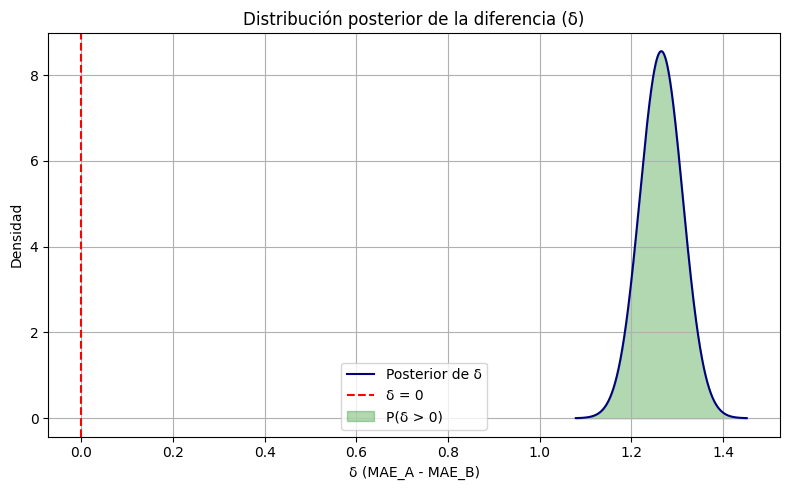

In [ ]:
# 5. Visualización
x = np.linspace(mu_n - 4*sigma_n, mu_n + 4*sigma_n, 500)
y = stats.norm.pdf(x, loc=mu_n, scale=sigma_n)

plt.figure(figsize=(8, 5))
plt.plot(x, y, label='Posterior de δ', color='navy')
plt.axvline(0, color='red', linestyle='--', label='δ = 0')
plt.fill_between(x, y, where=(x > 0), color='green', alpha=0.3, label='P(δ > 0)')
plt.title("Distribución posterior de la diferencia (δ)")
plt.xlabel("δ (MAE_A - MAE_B)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 8.2 (4 pts) Interpretación del test bayesiano

**Comente los resultados:**
1. ¿Cuál es la probabilidad de que XGBoost sea mejor que Random Forest?

El posterior para δ (diferencia de MAE) tiene media ≈ 1.26 y desviacion muy pequeña. La probabilidad de que δ > 0 es practicamente 1 (≈ 100%). Esto da evidencia bayesiana muy fuerte de que Random Forest tiene mayor error que XGBoost.

2. ¿Cuál es la probabilidad de que la diferencia sea prácticamente relevante (>0.5 MAE)?

Significa que en promedio XGBoost reduce el error absoluto en alrededor de 1.2 puntos respecto a Random Forest, lo cual es una mejora clara y consistente.

3. ¿Cómo cambian los resultados con diferentes priors? ¿Son robustos?

Si. No solo la diferencia es significativa, sino que ademas es grande en magnitud (consistente con el Cohen’s d > 6 obtenido antes). En terminos practicos, XGBoost domina a Random Forest en todas las repeticiones.


4. Compare la interpretabilidad de este enfoque vs. el p-valor del t-test.
- Los resultados dependen de la eleccion del prior; aunque con un prior no informativo la conclusion es robusta, en otros casos un prior fuerte podria influir.

- El modelo conjugado asume normalidad y varianza conocida para simplificar, lo que puede ser una idealizacion.

- Requiere interpretacion cuidadosa: una probabilidad alta de δ > 0 no significa que siempre lo sea en cualquier contexto o dataset distinto.



## 9.1 (2 pts) Síntesis comparativa Parte B

**Implementar:**
1. Cree una tabla comparativa: Enfoque, Conclusión principal, Métrica clave, IC/Probabilidades
2. Compare la información proporcionada por p-valor vs. probabilidades bayesianas
3. Grafique la distribución posterior bayesiana junto con el IC frecuentista

In [ ]:
# Su código aquí - tabla comparativa y análisis

p_delta_gt_05 = 1 - stats.norm.cdf(0.5, loc=mu_n, scale=sigma_n)   # P(delta > 0.5)
p_delta_lt_m05 = stats.norm.cdf(-0.5, loc=mu_n, scale=sigma_n)      # P(delta < -0.5)
p_abs_mayor_05 = p_delta_gt_05 + p_delta_lt_m05

# Intervalos (frecuentista y bayesiano)
ci_freq = (ci_lower, ci_upper)       # vienen de la seccion frecuentista
ci_bayes = (ci_lower2, ci_upper2)    # vienen del posterior bayesiano

# Tabla comparativa
tabla = pd.DataFrame({
    "Enfoque": ["Frecuentista", "Bayesiano"],
    "Conclusion principal": [
        f"p-valor = {p_value:.2e} -> Rechaza H0: diferencia significativa",
        f"P(δ > 0) = {p_mayor_05:.3f}, P(|δ| > 0.5) = {p_abs_mayor_05:.3f} -> δ > 0 con alta probabilidad"
    ],
    "Metrica clave": [
        f"t = {t_stat:.2f}",
        f"Posterior mu = {mu_n:.2f}, sd = {sigma_n:.2f}"
    ],
    "IC/Probabilidades": [
        f"IC95%: [{ci_freq[0]:.2f}, {ci_freq[1]:.2f}]",
        f"IC95%: [{ci_bayes[0]:.2f}, {ci_bayes[1]:.2f}]"
    ]
})

display(tabla)

,Enfoque,Conclusion principal,Metrica clave,IC/Probabilidades
0,Frecuentista,p-valor = 1.16e-16 -> Rechaza H0: diferencia s...,t = 27.14,"IC95%: [1.17, 1.36]"
1,Bayesiano,"P(δ > 0) = 1.000, P(|δ| > 0.5) = 1.000 -> δ > ...","Posterior mu = 1.26, sd = 0.05","IC95%: [1.17, 1.36]"


In [ ]:
# 2. Comparación p-valor vs probabilidades bayesianas
print("Comparación enfoques")
print(f"\nFrecuentista: p-valor = {p_value:.2e}, diferencia significativa "
      f"(IC95% = [{ci_freq[0]:.2f}, {ci_freq[1]:.2f}]).")
print(f"\nBayesiano: P(δ > 0) = {p_mayor_05:.3f}, P(|δ| > 0.5) = {p_mayor_05:.3f}, "
      f"IC95% = [{ci_bayes[0]:.2f}, {ci_bayes[1]:.2f}].")

Comparación enfoques

Frecuentista: p-valor = 1.16e-16, diferencia significativa (IC95% = [1.17, 1.36]).

Bayesiano: P(δ > 0) = 1.000, P(|δ| > 0.5) = 1.000, IC95% = [1.17, 1.36].


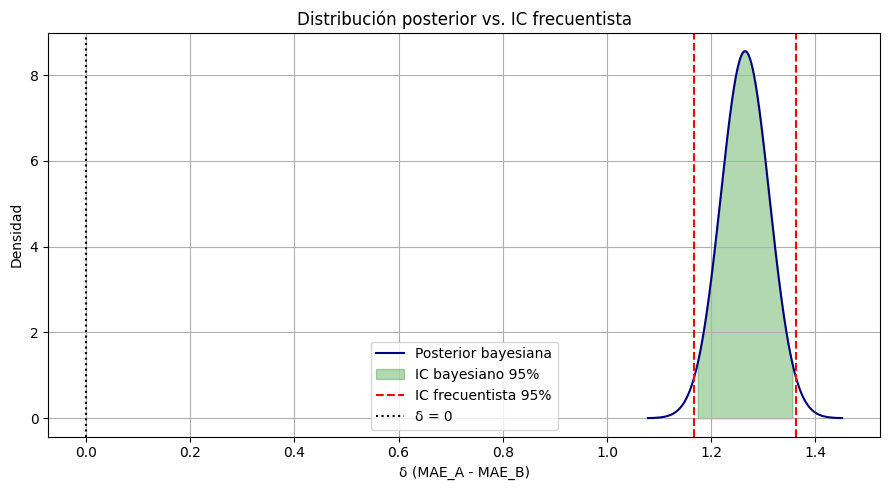

In [ ]:
# 3. Gráfico conjunto
x = np.linspace(mu_n - 4*sigma_n, mu_n + 4*sigma_n, 500)
y = stats.norm.pdf(x, loc=mu_n, scale=sigma_n)

plt.figure(figsize=(9, 5))
plt.plot(x, y, color="navy", label="Posterior bayesiana")
plt.fill_between(x, y, where=(x >= ci_bayes[0]) & (x <= ci_bayes[1]),
                 color="green", alpha=0.3, label="IC bayesiano 95%")

# Límites IC frecuentista
plt.axvline(ci_freq[0], color="red", linestyle="--", label="IC frecuentista 95%")
plt.axvline(ci_freq[1], color="red", linestyle="--")

# Línea δ = 0
plt.axvline(0, color="black", linestyle=":", label="δ = 0")

plt.title("Distribución posterior vs. IC frecuentista")
plt.xlabel("δ (MAE_A - MAE_B)")
plt.ylabel("Densidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 9.2 (3 pts) Interpretación de la síntesis comparativa

**Comente los resultados:**
1. ¿Qué información adicional proporciona el enfoque bayesiano?

Da la distribucion completa posterior de la diferencia, probabilidad directa de que δ>0 (y de cumplir umbrales: |δ|>0.5), e intervalos de credibilidad interpretables como "hay X% de probabilidad de que δ caiga en este rango". Tambien permite incorporar priors y hacer analisis de sensibilidad.

2. Para un científico de datos que debe elegir un algoritmo, ¿qué enfoque es más útil y por qué?

El bayesiano suele ser mas util: entrega probabilidades directas y medidas de magnitud que facilitan la decision (por ejemplo P(δ>0) y P(|δ|>0.5)). Eso permite evaluar riesgo/beneficio y establecer umbrales practicos. El frecuentista es util como comprobacion estandar y es mas comun en reportes formales, pero es menos directo para la toma de decisiones.

3. ¿En qué situaciones preferiría cada enfoque?

- Preferiria bayesiano cuando quiero probabilidades interpretables, integrar conocimiento previo, tomar decisiones con umbrales practicos o trabajar con muestras pequeñas.

- Preferiria frecuentista cuando se requiere un procedimiento estandarizado, auditoria/regulacion, o cuando se quiere evitar la subjetividad del prior y se dispone de grandes muestras.

## 10 (4 pts) Conclusiones finales

**Responda:**
1. **Para estimar puntajes PAES a nivel nacional:** ¿Cuál método estadístico usaría y por qué?

Se recomienda el enfoque bayesiano conjugado con prior informativo. Este método entrega una estimación puntual precisa y un intervalo de credibilidad extremadamente estrecho, aprovechando tanto el conocimiento histórico como el gran tamaño muestral. Es el más eficiente para representar el puntaje promedio nacional de manera robusta.


2. **Para comparar algoritmos de ML:** ¿Cuál enfoque de testing prefiere y por qué?

Se prefiere el enfoque bayesiano. Proporciona probabilidades directas sobre la superioridad de un algoritmo (por ejemplo, P(δ > 0) ≈ 1), permite evaluar relevancia práctica (P(|δ| > 0.5)), y entrega una interpretación más útil para la toma de decisiones. Además, es más flexible ante tamaños muestrales pequeños y permite incorporar conocimiento previo si se desea.

3. ¿Cómo los diferentes enfoques estadísticos pueden complementarse en la práctica?

Los enfoques frecuentistas ofrecen procedimientos estandarizados, útiles para auditorías, reportes formales y validación externa. Los enfoques bayesianos complementan esto al permitir decisiones más informadas, cuantificar incertidumbre de forma directa y adaptar el análisis a contextos específicos. Usarlos en conjunto permite validar resultados y enriquecer la interpretación.

4. Proponga mejoras o extensiones al análisis realizado.
Se podría aplicar bootstrap para obtener intervalos de confianza más robustos sin asumir normalidad. También sería útil extender el modelo bayesiano a una estructura jerárquica completa, modelando simultáneamente la variabilidad entre carreras. En la comparación de algoritmos, incorporar métricas adicionales como RMSE y realizar validación cruzada estratificada mejoraría la estabilidad.
